# Activity 3 — Multi-format Data Loading & Visualization

**Files required:** `students.csv`, `attendance.json`, `extra.xlsx`

Place the three files in the same folder as this notebook.

Expected information:
- `students.csv` → Name, Marks
- `attendance.json` → Name, Attendance
- `extra.xlsx` → Name, Bonus

### How it works
Pandas has separate readers for common formats:
- `read_csv()` for CSV
- `read_json()` for JSON
- `read_excel()` for Excel

In [6]:
%pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   --------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\PMLS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

students = pd.read_csv("Data/students.csv")
attendance = pd.read_json("Data/attendance.json")
extra = pd.read_excel("Data/extra.xlsx")

print("Students:")
print(students.head())

print("\nAttendance:")
print(attendance.head())

print("\nExtra:")
print(extra.head())

Students:
     Name  Marks
0     Ali     85
1  Hassan     72
2    Sara     91
3  Ayesha     65
4   Bilal     78

Attendance:
     Name  Attendance
0     Ali          92
1  Hassan          78
2    Sara          95
3  Ayesha          68
4   Bilal          82

Extra:
     Name  Bonus
0     Ali      5
1  Hassan      3
2    Sara      4
3  Ayesha      2
4   Bilal      5


## Task 1 — Merge the three DataFrames

We merge using `Name`, because it identifies the student across all three files.

`how="inner"` keeps only students that appear in all three files.

In [8]:
df = students.merge(attendance, on="Name", how="inner")
df = df.merge(extra, on="Name", how="inner")

df = df[["Name", "Marks", "Attendance", "Bonus"]]

print(df)

     Name  Marks  Attendance  Bonus
0     Ali     85          92      5
1  Hassan     72          78      3
2    Sara     91          95      4
3  Ayesha     65          68      2
4   Bilal     78          82      5
5    Hira     58          55      1
6   Usman     88          89      4
7    Zara     69          64      2


## Task 2 — Scatter plot of Marks vs Attendance

Students with attendance below 70% are highlighted separately.

The two conditions are:
- normal students: Attendance >= 70
- low attendance: Attendance < 70

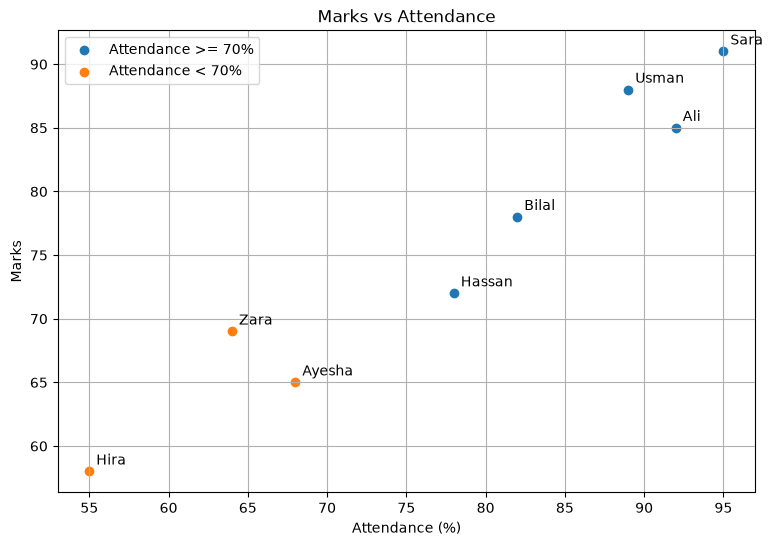

In [9]:
low_attendance = df["Attendance"] < 70

plt.figure(figsize=(9, 6))

plt.scatter(
    df.loc[~low_attendance, "Attendance"],
    df.loc[~low_attendance, "Marks"],
    label="Attendance >= 70%"
)

plt.scatter(
    df.loc[low_attendance, "Attendance"],
    df.loc[low_attendance, "Marks"],
    label="Attendance < 70%"
)

for _, row in df.iterrows():
    plt.annotate(
        row["Name"],
        (row["Attendance"], row["Marks"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Attendance (%)")
plt.ylabel("Marks")
plt.title("Marks vs Attendance")
plt.legend()
plt.grid(True)
plt.show()

## Task 3 — One-hot encode Name

One-hot encoding creates one binary column for each name.

This is mainly a demonstration of categorical encoding. In a real ML model, encoding a student's name as a feature usually would not be meaningful because the name itself does not represent a useful numerical characteristic.

In [10]:
encoded_names = pd.get_dummies(df["Name"], prefix="Name")

df_encoded = pd.concat([df, encoded_names], axis=1)

print(df_encoded)

     Name  Marks  Attendance  Bonus  Name_Ali  Name_Ayesha  Name_Bilal  \
0     Ali     85          92      5      True        False       False   
1  Hassan     72          78      3     False        False       False   
2    Sara     91          95      4     False        False       False   
3  Ayesha     65          68      2     False         True       False   
4   Bilal     78          82      5     False        False        True   
5    Hira     58          55      1     False        False       False   
6   Usman     88          89      4     False        False       False   
7    Zara     69          64      2     False        False       False   

   Name_Hassan  Name_Hira  Name_Sara  Name_Usman  Name_Zara  
0        False      False      False       False      False  
1         True      False      False       False      False  
2        False      False       True       False      False  
3        False      False      False       False      False  
4        False      Fal